<a href="https://colab.research.google.com/github/jenny005/Reinforcement-Learning-by-Sutton-Barto/blob/main/The_Backprop_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

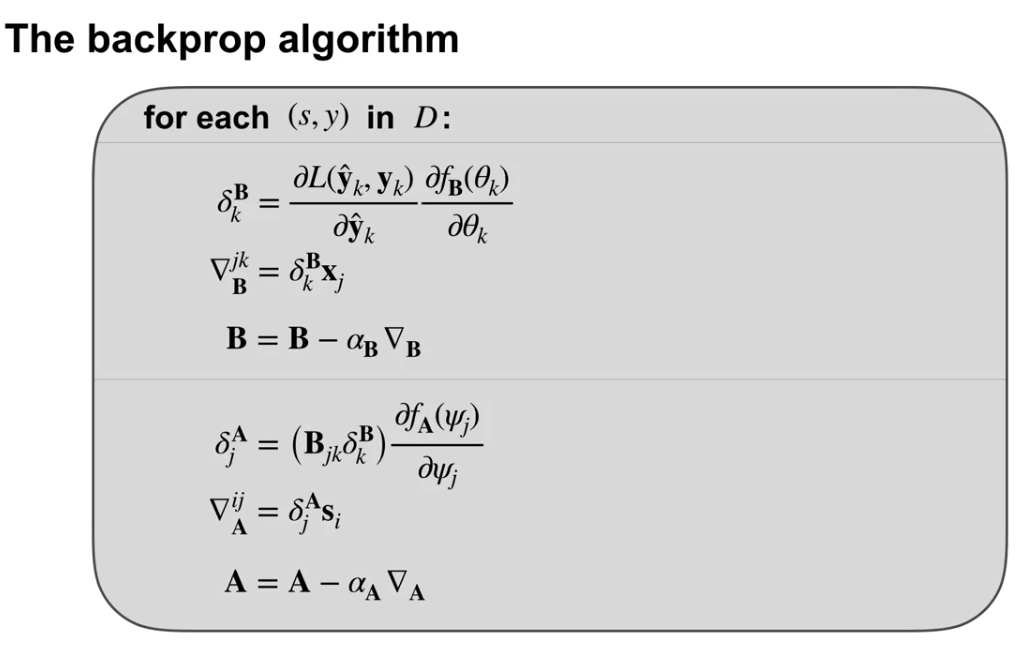

In [ ]:
import numpy as np

# Activation functions and their derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# Mean Squared Error loss and derivative
def mse_loss(y_hat, y):
    return 0.5 * np.sum((y_hat - y)**2)

def mse_derivative(y_hat, y):
    return y_hat - y

# Forward pass
def forward_pass(x, A, B):
    z_hidden = A @ x        # linear part for hidden layer
    s = sigmoid(z_hidden)   # activation output of hidden layer
    z_output = B @ s
    y_hat = sigmoid(z_output)
    return z_hidden, s, z_output, y_hat

# Backward pass (one training example)
def backward_pass(x, y, A, B, alpha_A, alpha_B):
    # --- Forward ---
    z_hidden, s, z_output, y_hat = forward_pass(x, A, B)

    # --- Output Layer (B) ---
    delta_B = mse_derivative(y_hat, y) * sigmoid_derivative(z_output)
    grad_B = np.outer(delta_B, s)
    B -= alpha_B * grad_B

    # --- Hidden Layer (A) ---
    delta_A = (B.T @ delta_B) * sigmoid_derivative(z_hidden)
    grad_A = np.outer(delta_A, x)
    A -= alpha_A * grad_A

    return A, B, mse_loss(y_hat, y)

# Training loop
def train(X, Y, input_dim, hidden_dim, output_dim, epochs=1000, alpha_A=0.1, alpha_B=0.1):
    A = np.random.randn(hidden_dim, input_dim) * 0.1  # weights to hidden
    B = np.random.randn(output_dim, hidden_dim) * 0.1 # weights to output

    for epoch in range(epochs):
        total_loss = 0
        for x, y in zip(X, Y):
            A, B, loss = backward_pass(x, y, A, B, alpha_A, alpha_B)
            total_loss += loss
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {total_loss:.4f}")
    return A, B


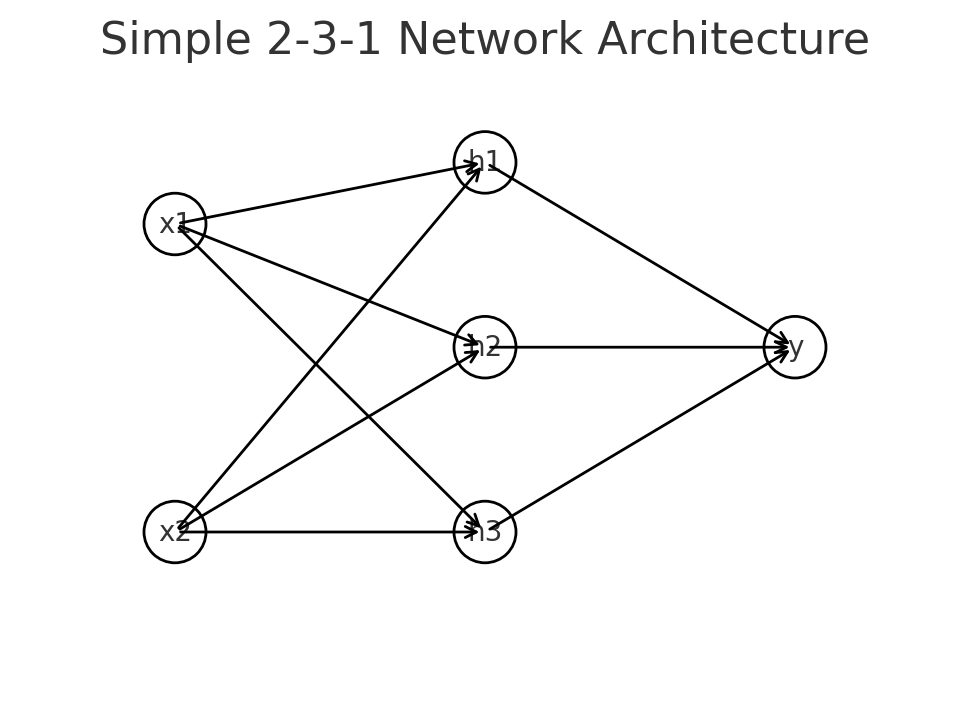

In [ ]:
x = np.array([0.1, 0.2])           # input vector (2D)

# A: weights to 3 hidden units from 2 input units (shape: 3x2)
A = np.array([
    [0.5, -0.6],
    [0.3, 0.8],
    [-0.2, 0.1]
])

# B: weights to 1 output from 3 hidden units (shape: 1x3)
B = np.array([
    [0.2, -0.5, 0.4]
])

# Perform forward pass
z_hidden, s, z_output, y_hat = forward_pass(x, A, B)
print("y_hat =", y_hat)


y_hat = [0.50570541]


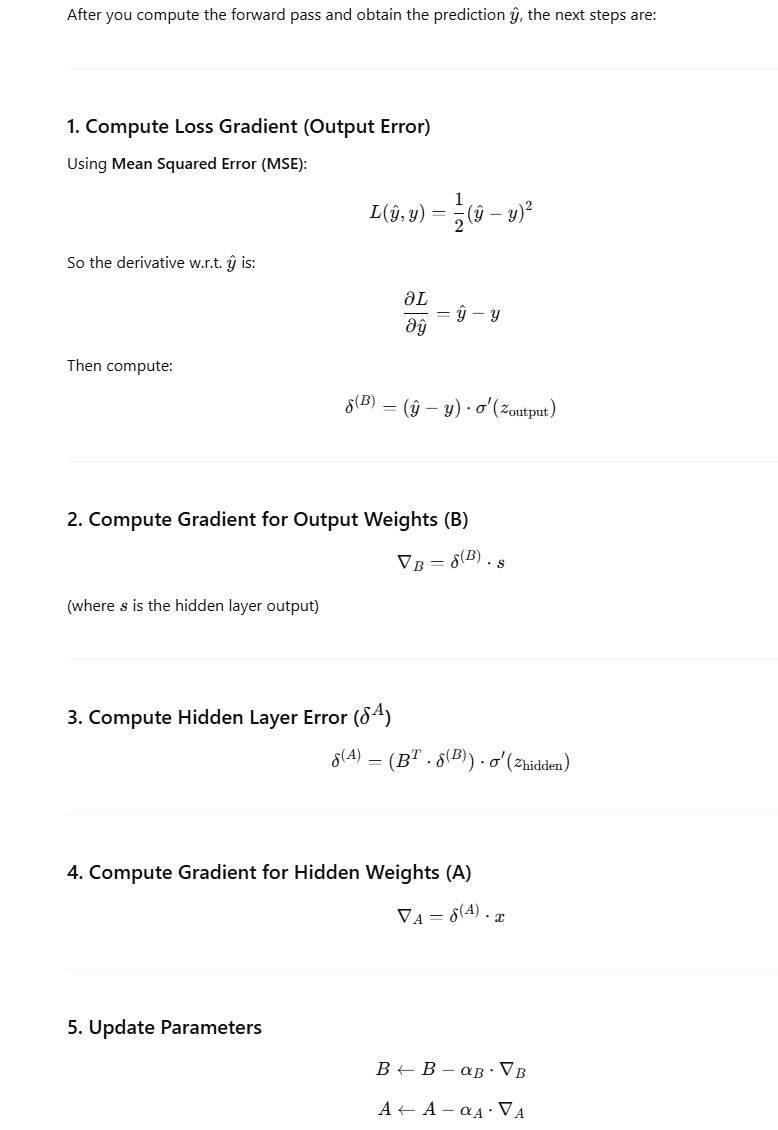

In [ ]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def backward_pass(x, y, A, B, alpha_A, alpha_B):
    # --- Forward pass ---
    z_hidden, s, z_output, y_hat = forward_pass(x, A, B)

    # --- Output layer delta ---
    delta_B = (y_hat - y) * sigmoid_derivative(z_output)  # shape: (1,)

    # Gradient for B: (1,3)
    grad_B = delta_B.T @ s[np.newaxis, :]                 # shape: (1,3)

    # --- Hidden layer delta ---
    delta_A = (B.T @ delta_B) * sigmoid_derivative(z_hidden)  # shape: (3,)

    # Gradient for A: (3,2)
    grad_A = delta_A[:, np.newaxis] @ x[np.newaxis, :]        # outer product

    # --- Update weights ---
    B -= alpha_B * grad_B
    A -= alpha_A * grad_A

    # --- Return updated weights and loss ---
    loss = 0.5 * np.sum((y_hat - y)**2)
    return A, B, loss


In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Inputs and targets
x = np.array([0.05, 0.10])
t = np.array([0.01, 0.99])  # two targets for the two outputs
η = 0.5

# Initial weights & biases for a 2‑3‑2 network
w = np.array([
    [0.15, 0.20],   # w11, w12
    [0.25, 0.30],   # w21, w22
    [0.35, 0.35]    # w31, w32
])                 # shape (3 hidden × 2 inputs)
b1 = np.array([0.35, 0.35, 0.35])   # hidden biases (3,)

v = np.array([
    [0.40, 0.45, 0.50],  # v1 weights to h1,h2,h3
    [0.50, 0.55, 0.60]   # v2 weights to h1,h2,h3
])                 # shape (2 outputs × 3 hidden)
b2 = np.array([0.60, 0.60])  # output biases (2,)

# --- Forward pass ---
z1 = w @ x + b1         # (3,)
a1 = sigmoid(z1)        # (3,)
z2 = v @ a1 + b2        # (2,)
y  = sigmoid(z2)        # (2,)

# --- Compute loss ---
E = 0.5 * np.sum((t - y)**2)
print("Initial loss:", E)

# --- Backward pass ---
δ_o   = (y - t) * y * (1 - y)        # (2,)
dE_dv = np.outer(δ_o, a1)            # (2,3)
dE_db2 = δ_o                         # (2,)

δ_h   = (v.T @ δ_o) * a1 * (1 - a1)   # (3,)
dE_dw = np.outer(δ_h, x)             # (3,2)
dE_db1 = δ_h                         # (3,)

# --- Update ---
v  -= η * dE_dv
b2 -= η * dE_db2
w  -= η * dE_dw
b1 -= η * dE_db1

# --- Results ---
print("\nNew hidden weights (w):\n", w)
print("New hidden biases (b1):\n", b1)
print("New output weights (v):\n", v)
print("New output biases (b2):\n", b2)
